## Cosmological Distances from DESI Data

In this notebook, we compute and plot two key cosmological distance measures:

- **Comoving Angular Diameter Distance** $ D_M(z) $
- **Hubble Distance** $ D_H(z) = \frac{c}{H(z)} $

We overlay theoretical predictions from CAMB (using our MCMC-derived best-fit parameters) with observational data points from the DESI survey.


In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
from getdist import plots, MCSamples
import getdist
import camb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython
print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))

/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


GetDist Version: 1.5.4, Matplotlib version: 3.9.2


### Extract DESI data
I extract data for DESI DR2 and then for DESI DR1

In [2]:
# Read file with DESI data DR2
# Measurements of distances
df_val = pd.read_csv(
    "/home/andrewcats/tesi_magistrale/lcdm/points/desi_dr2_points/desi_gaussian_bao_ALL_GCcomb_mean.txt",
    sep='\s+',
    header=None,
    names=["z", "value", "quantity"],
    comment='#'
)

# Matrix of covariance
df_err = pd.read_csv(
    "/home/andrewcats/tesi_magistrale/lcdm/points/desi_dr2_points/desi_gaussian_bao_ALL_GCcomb_cov.txt",
    sep='\s+',
    header=None,
)

cov_matrix = df_err.values
errors = np.sqrt(np.diag(cov_matrix))

# Attach errors (in same order)
df_val["error"] = errors

# Check
print(df_val.head())
print(df_err.shape)   
print(df_val.shape[0])

       z      value    quantity     error
0  0.295   7.941676  DV_over_rs  0.076092
1  0.510  13.587584  DM_over_rs  0.168367
2  0.510  21.862947  DH_over_rs  0.428868
3  0.706  17.350691  DM_over_rs  0.179931
4  0.706  19.455349  DH_over_rs  0.333870
(13, 13)
13


In [3]:
# Extract real points from DESI DR1
# Measurements of distances
df_val_dr1 = pd.read_csv(
    "/home/andrewcats/tesi_magistrale/lcdm/points/desi_dr1_points/desi_2024_gaussian_bao_ALL_GCcomb_mean.txt",
    sep='\s+',
    header=None,
    names=["z", "value", "quantity"],
    comment='#'
)

# Matrix of covariance
df_err_dr1 = pd.read_csv(
    "/home/andrewcats/tesi_magistrale/lcdm/points/desi_dr1_points/desi_2024_gaussian_bao_ALL_GCcomb_cov.txt",
    sep='\s+',
    header=None,
)

cov_matrix_dr1 = df_err_dr1.values
errors_dr1 = np.sqrt(np.diag(cov_matrix_dr1))

# Attach errors (in same order)
df_val_dr1["error"] = errors_dr1

# Check
print(df_val_dr1.head())
print(df_err_dr1.shape)   
print(df_val_dr1.shape[0])

       z      value    quantity     error
0  0.295   7.925129  DV_over_rs  0.150742
1  0.510  13.620031  DM_over_rs  0.251925
2  0.510  20.983346  DH_over_rs  0.610712
3  0.706  16.846453  DM_over_rs  0.319336
4  0.706  20.078729  DH_over_rs  0.595356
(12, 12)
12


In [4]:
# DR2
# Transverse comoving distance
dm = df_val[df_val["quantity"] == "DM_over_rs"]

# Hubble distance
dh = df_val[df_val["quantity"] == "DH_over_rs"]

# DR1
# Transverse comoving distance
dm_dr1 = df_val_dr1[df_val_dr1["quantity"] == "DM_over_rs"]

# Hubble distance
dh_dr1 = df_val_dr1[df_val_dr1["quantity"] == "DH_over_rs"]

Read best fit parameters from the file txt

In [5]:
# DR2
# Load best-fit parameters from file
columns = [
    "minuslogpost", "H0", "logA", "ns", "ombh2", "omch2", "tau",
    "A", "As", "DHBBN", "YHe", "Y_p", "age", "clamp", "omega_de", "omegam",
    "omegamh2", "rdrag", "s8h5", "S8_optimal", "s8omegamp25", "s8omegamp5",
    "sigma8", "thetastar", "zrei", "chi2__BAO", "minuslogprior",
    "minuslogprior__0", "chi2", "chi2__bao.desi_dr2.desi_bao_all"
]

df = pd.read_csv("/home/andrewcats/tesi_magistrale/lcdm/desidr2/minimize/lcdm_desidr2_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns)

# Extract values
H0_best = df["H0"].values[0]
ombh2_best = df["ombh2"].values[0]
omch2_best = df["omch2"].values[0]
tau_best = df["tau"].values[0]
ns_best = df["ns"].values[0]
logA_best = df["logA"].values[0]
As_best = logA = df["As"].values[0]
rdrag_best = df["rdrag"].values[0]

# DR1
# Load best-fit parameters from file
columns_dr1 = [
    "minuslogpost", "H0", "logA", "ns", "ombh2", "omch2", "tau",
    "A", "As", "DHBBN", "YHe", "Y_p", "age", "clamp", "omega_de", "omegam",
    "omegamh2", "rdrag", "s8h5", "S8_optimal", "s8omegamp25", "s8omegamp5",
    "sigma8", "thetastar", "zrei", "chi2__BAO", "minuslogprior",
    "minuslogprior__0", "chi2", "chi2__bao.desi_2024_bao_all"
]

df = pd.read_csv("/home/andrewcats/tesi_magistrale/lcdm/desidr1/minimize/lcdm_desidr1_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_dr1)


# Extract values
H0_dr1 = df["H0"].values[0]
ombh2_dr1 = df["ombh2"].values[0]
omch2_dr1 = df["omch2"].values[0]
tau_dr1 = df["tau"].values[0]
ns_dr1 = df["ns"].values[0]
logA_dr1 = df["logA"].values[0]
As_dr1 = logA = df["As"].values[0]
rdrag_dr1 = df["rdrag"].values[0]

# Now for DR2 EXP
columns_exp = [
    "minuslogpost", "H0", "logA", "ns", "ombh2", "omch2", "tau", "EFT_lambda",
    "A", "As", "DHBBN", "YHe", "Y_p", "age", "clamp", "omega_de", "omegam",
    "omegamh2", "rdrag", "s8h5", "S8_optimal", "s8omegamp25", "s8omegamp5",
    "sigma8", "thetastar", "zrei", "chi2__BAO", "minuslogprior",
    "minuslogprior__0", "chi2", "chi2__bao.desi_dr2.desi_bao_all"
]

df_exp = pd.read_csv("/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/desidr2/minimize/1_EXP_lcdm_desidr2_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_exp)

# Extract values
H0_exp = df_exp["H0"].values[0]
ombh2_exp = df_exp["ombh2"].values[0]
omch2_exp = df_exp["omch2"].values[0]
tau_exp = df_exp["tau"].values[0]
ns_exp = df_exp["ns"].values[0]
logA_exp = df_exp["logA"].values[0]
As_exp = logA = df_exp["As"].values[0]
rdrag_exp = df_exp["rdrag"].values[0]

/tmp/ipykernel_5094/3142078675.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("/home/andrewcats/tesi_magistrale/lcdm/desidr2/minimize/lcdm_desidr2_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns)
/tmp/ipykernel_5094/3142078675.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("/home/andrewcats/tesi_magistrale/lcdm/desidr1/minimize/lcdm_desidr1_min.minimum.txt", delim_whitespace=True, skiprows=1, names=columns_dr1)
/tmp/ipykernel_5094/3142078675.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_exp = pd.read_csv("/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/desidr2/minimize/1_EXP_lcdm_desidr2_min.minimu

### Compute distances

In [6]:
# DR2
# Set CAMB parameters
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0_best, ombh2=ombh2_best, omch2=omch2_best, tau=tau_best)
pars.InitPower.set_params(ns=ns_best, As=As_best)
pars.set_for_lmax(0)
pars.DoLensing = False
results_best = camb.get_results(pars)


# Initialize lists to store distances
dc_list_best = []
da_list_best = []
dl_list_best = []
dm_list_best = [] # comoving angular diameter distance
dh_list_best = [] # Hubble distance

c = 2.99792458e5 # speed of light in km/s
z = np.linspace(0, 3, 1000) # redshift range

for i in z:
    dc_list_best.append(results_best.comoving_radial_distance(i)/rdrag_best)
    da_list_best.append(results_best.angular_diameter_distance(i)/rdrag_best)
    dl_list_best.append(results_best.luminosity_distance(i)/rdrag_best)
    dh_list_best.append((c/results_best.hubble_parameter(i))/rdrag_best) # Hubble distance

# Convert lists to arrays
dc_rs_best = np.array(dc_list_best)
da_rs_best = np.array(da_list_best)
dl_rs_best = np.array(dl_list_best)
dh_rs_best = np.array(dh_list_best)

'''
# Plot distances vs redshift in 2 different panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12), sharex=True)

ax1.errorbar(dh["z"], dh["value"], yerr=dh["error"], fmt='o', label=r"$D_H/r_s$")
ax1.plot(z, dh_rs_best, label='Hubble Distance')
ax1.set_ylabel('Distance/rs')
ax1.legend()

ax2.plot(z, dc_rs_best, label='Comoving Angular Diameter Distance')
ax2.errorbar(dm["z"], dm["value"], yerr=dm["error"], fmt='o', label=r"$D_M/r_s$")
ax2.set_ylabel('Distance/rs')
ax2.legend()
'''

'\n# Plot distances vs redshift in 2 different panels\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12), sharex=True)\n\nax1.errorbar(dh["z"], dh["value"], yerr=dh["error"], fmt=\'o\', label=r"$D_H/r_s$")\nax1.plot(z, dh_rs_best, label=\'Hubble Distance\')\nax1.set_ylabel(\'Distance/rs\')\nax1.legend()\n\nax2.plot(z, dc_rs_best, label=\'Comoving Angular Diameter Distance\')\nax2.errorbar(dm["z"], dm["value"], yerr=dm["error"], fmt=\'o\', label=r"$D_M/r_s$")\nax2.set_ylabel(\'Distance/rs\')\nax2.legend()\n'

In [7]:
# DR1
# Compute distances

# Set CAMB parameters
pars_dr1 = camb.CAMBparams()
pars_dr1.set_cosmology(H0=H0_dr1, ombh2=ombh2_dr1, omch2=omch2_dr1, tau=tau_dr1)
pars_dr1.InitPower.set_params(ns=ns_dr1, As=As_dr1)
pars_dr1.set_for_lmax(0)
pars_dr1.DoLensing = False
results_dr1 = camb.get_results(pars_dr1)


# Initialize lists to store distances
dc_list_dr1 = [] # comoving distance
#da_list_dr1 = []
#dl_list_dr1 = []
dm_list_dr1 = [] # comoving angular diameter distance
dh_list_dr1 = [] # Hubble distance

for i in z:
    dc_list_dr1.append(results_dr1.comoving_radial_distance(i)/rdrag_dr1)
    #da_list_dr1.append(results_dr1.angular_diameter_distance(i)/rdrag_dr1)
    #dl_list_dr1.append(results_dr1.luminosity_distance(i)/rdrag_dr1)
    dh_list_dr1.append((c/results_dr1.hubble_parameter(i))/rdrag_dr1) 

# Convert lists to arrays
dc_rs_dr1 = np.array(dc_list_dr1)
#da_rs_dr1 = np.array(da_list_dr1)
#dl_rs_dr1 = np.array(dl_list_dr1)
dh_rs_dr1 = np.array(dh_list_dr1)


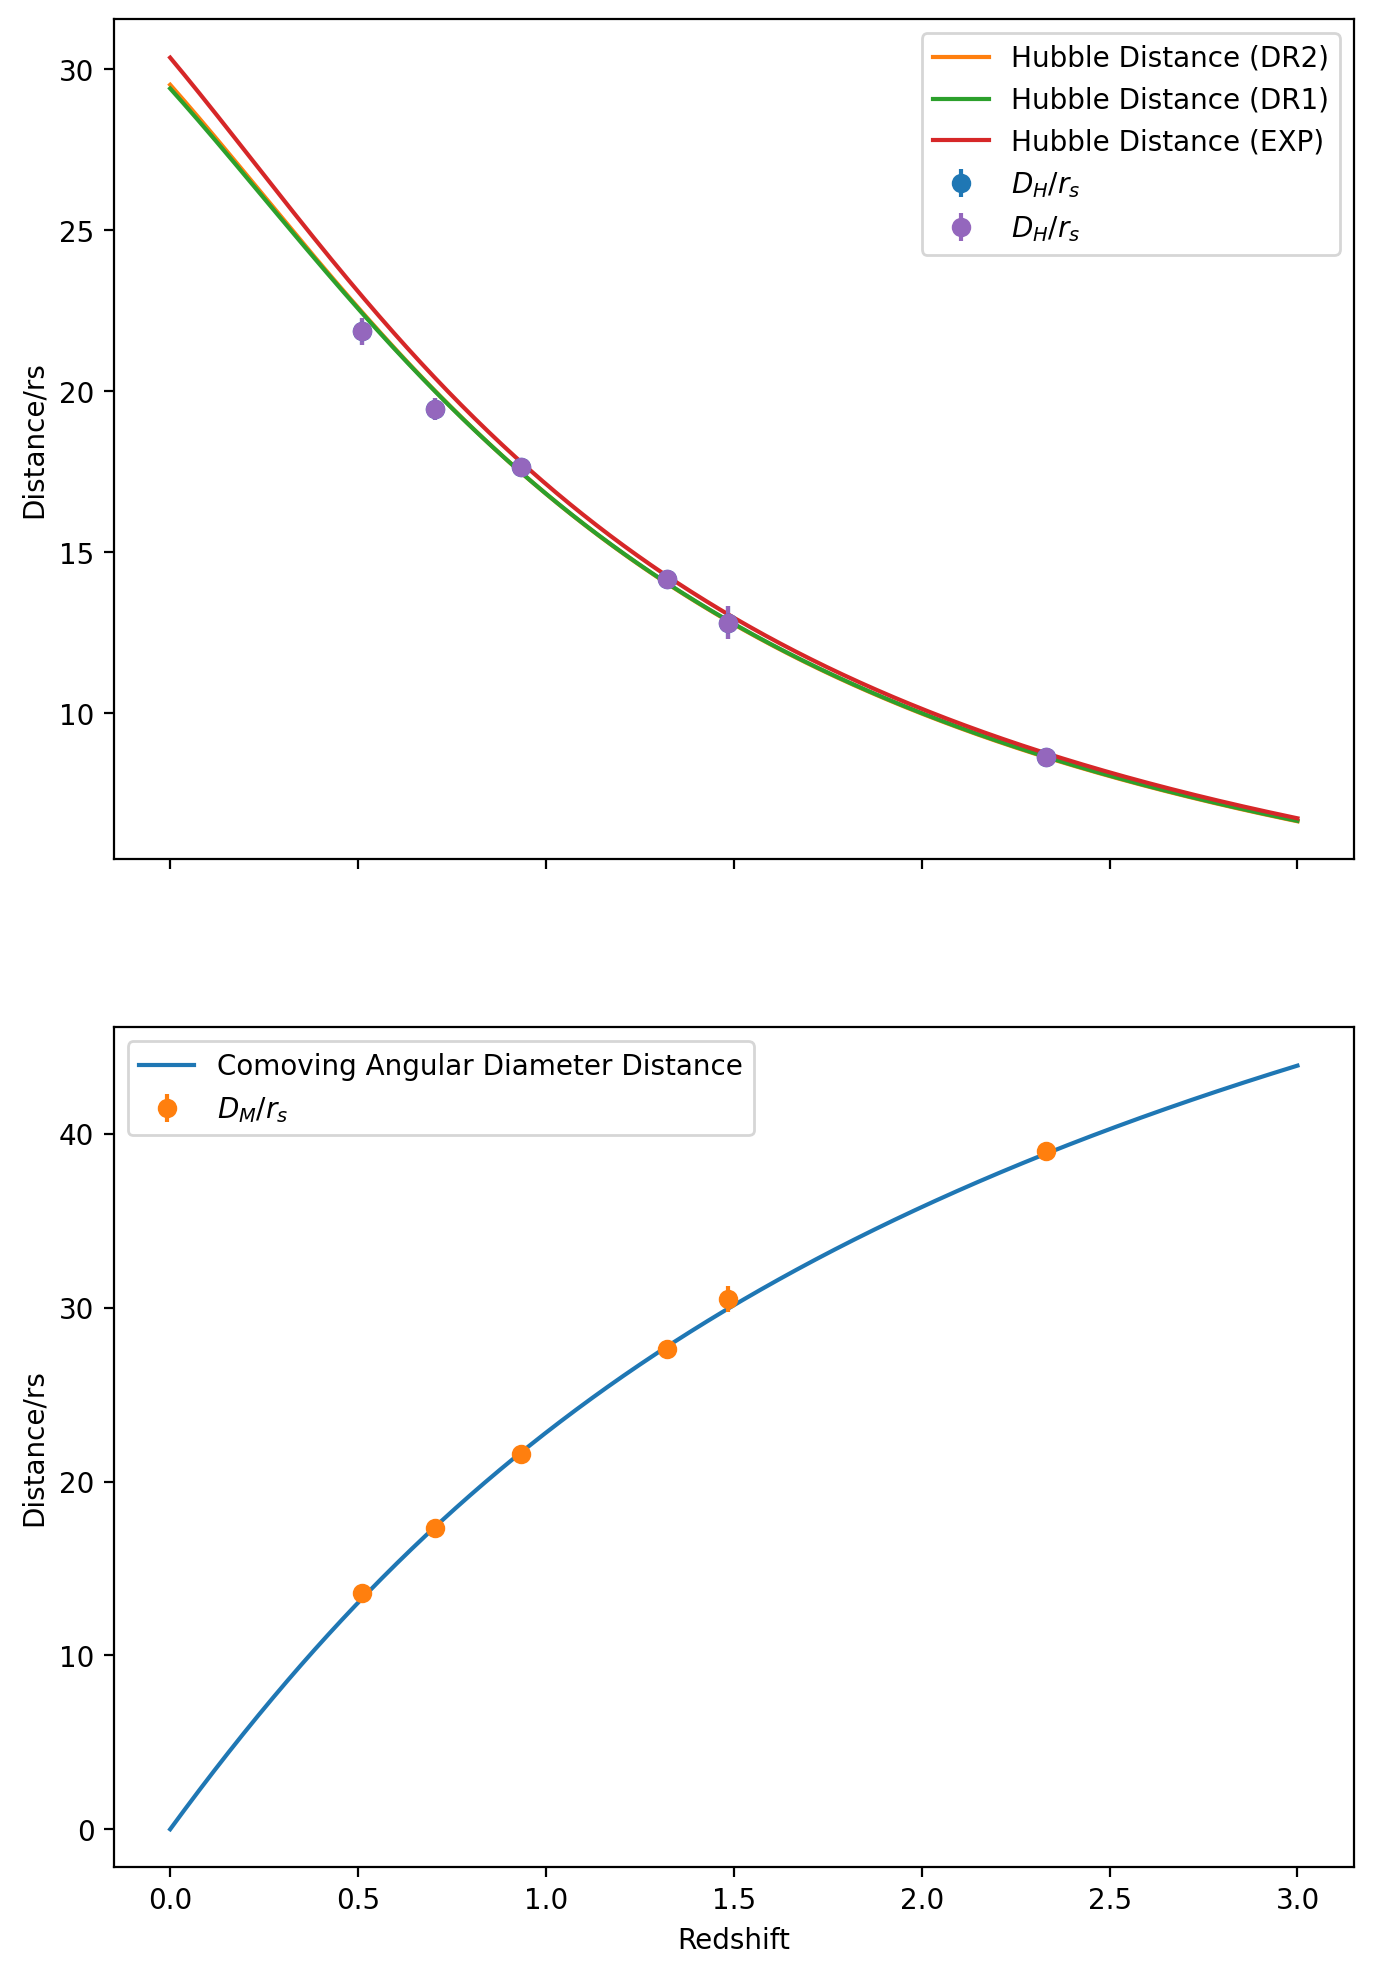

In [8]:
# DR2 EXP
# Compute distances

# Set CAMB parameters
pars_exp = camb.CAMBparams()
pars_exp.set_cosmology(H0=H0_exp, ombh2=ombh2_exp, omch2=omch2_exp, tau=tau_exp)
pars_exp.InitPower.set_params(ns=ns_exp, As=As_exp)
pars_exp.set_for_lmax(0)
pars_exp.DoLensing = False
results_exp = camb.get_results(pars_exp)

# Initialize lists to store distances
dc_list_exp = [] # comoving distance
#da_list_exp = []
#dl_list_exp = []
dm_list_exp = [] # comoving angular diameter distance
dh_list_exp = [] # Hubble distance

for i in z:
    dc_list_exp.append(results_exp.comoving_radial_distance(i)/rdrag_exp)
    #da_list_exp.append(results_exp.angular_diameter_distance(i)/rdrag_exp)
    #dl_list_exp.append(results_exp.luminosity_distance(i)/rdrag_exp)
    dh_list_exp.append((c/results_exp.hubble_parameter(i))/rdrag_exp)

# Convert lists to arrays
dc_rs_exp = np.array(dc_list_exp)
#da_rs_exp = np.array(da_list_exp)
#dl_rs_exp = np.array(dl_list_exp)
dh_rs_exp = np.array(dh_list_exp)

# Plot distances vs redshift in 2 different panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12), sharex=True)
ax1.errorbar(dh["z"], dh["value"], yerr=dh["error"], fmt='o', label=r"$D_H/r_s$")
ax1.plot(z, dh_rs_best, label='Hubble Distance (DR2)')
ax1.plot(z, dh_rs_dr1, label='Hubble Distance (DR1)')
ax1.plot(z, dh_rs_exp, label='Hubble Distance (EXP)')
ax1.errorbar(dh["z"], dh["value"], yerr=dh["error"], fmt='o', label=r"$D_H/r_s$")
ax1.set_ylabel('Distance/rs')
ax1.legend()
ax2.plot(z, dc_rs_best, label='Comoving Angular Diameter Distance')
ax2.errorbar(dm["z"], dm["value"], yerr=dm["error"], fmt='o', label=r"$D_M/r_s$")
ax2.set_ylabel('Distance/rs')
ax2.legend()
plt.xlabel('Redshift')
plt.show()

Now, I make the residual plot

In [9]:
# DR2

# Interpolate CAMB model onto DESI z
from scipy.interpolate import interp1d

dm_model_interp = interp1d(z, dc_rs_best, kind='cubic')
dm_model_at_dataz = dm_model_interp(dm["z"])

# Compute ratio and error
ratio = dm["value"] / dm_model_at_dataz
ratio_err = dm["error"] / dm_model_at_dataz


# DR1
dm_model_interp_dr1 = interp1d(z, dc_rs_dr1, kind='cubic')
dm_model_at_dataz_dr1 = dm_model_interp_dr1(dm_dr1["z"])

# Compute ratio and error
ratio_dr1 = dm_dr1["value"] / dm_model_at_dataz_dr1
ratio_err_dr1 = dm_dr1["error"] / dm_model_at_dataz_dr1


# DR2 EXP
dm_model_interp_exp = interp1d(z, dc_rs_exp, kind='cubic')
dm_model_at_dataz_exp = dm_model_interp_exp(dm["z"])

# Compute ratio and error
ratio_exp = dm["value"] / dm_model_at_dataz_exp
ratio_err_exp = dm["error"] / dm_model_at_dataz_exp

In [ ]:
from matplotlib import cm

# Get values as arrays (DR2)
z_vals = dm["z"].to_numpy()
ratio = (dm["value"] / dm_model_at_dataz).to_numpy()
ratio_err = (dm["error"] / dm_model_at_dataz).to_numpy()
print("Redshift values:", z_vals)

# Get values as arrays (DR1)
z_vals_dr1 = dm_dr1["z"].to_numpy()
ratio_dr1 = (dm_dr1["value"] / dm_model_at_dataz_dr1).to_numpy()
ratio_err_dr1 = (dm_dr1["error"] / dm_model_at_dataz_dr1).to_numpy()
print("Redshift values:", z_vals_dr1)

# Normalize across full redshift range for consistent colormap
all_z = np.concatenate([z_vals, z_vals_dr1])
norm = plt.Normalize(vmin=all_z.min(), vmax=all_z.max())
cmap = cm.viridis_r

colors_dr2 = cmap(norm(z_vals))
colors_dr1 = cmap(norm(z_vals_dr1))

plt.figure(figsize=(8, 5))

# Plot DR2 points + error bars
for i in range(len(z_vals)):
    plt.errorbar(
        z_vals[i], ratio[i],
        yerr=ratio_err[i],
        fmt='o',
        markerfacecolor=colors_dr2[i],
        markeredgecolor='black',
        ecolor=colors_dr2[i],
        markersize=8,
        capsize=4,
        label='DESI DR2' if i == 0 else None,
        zorder=3
    )

# Plot DR1 points + error bars
for i in range(len(z_vals_dr1)):
    plt.errorbar(
        z_vals_dr1[i], ratio_dr1[i],
        yerr=ratio_err_dr1[i],
        fmt='s',  # square marker to distinguish
        markerfacecolor=colors_dr1[i],
        markeredgecolor='black',
        ecolor=colors_dr1[i],
        markersize=8,
        capsize=4,
        label='DESI DR1' if i == 0 else None,
        zorder=2
    )

# Colorbar for shared redshift
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax = plt.gca()
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Redshift $z$')

# Plot Distance(with exp)/Distance(with lcdm) vs redshift

# Compute ratio:
R_list = [] # ratio between distances (exp/lcdm)

z_list = np.linspace(0.001, 2.7, 1000) # redshift range

for i in z_list:
    R_list.append(results_exp.comoving_radial_distance(i) / results_best.comoving_radial_distance(i))

R = np.array(R_list)

plt.plot(z_list, R, label='Ratio (EXP/LCDM)', color='blue')

# Horizontal reference line
plt.axhline(1.0, color='gray', linestyle='--')

# Labels and aesthetics
plt.xlabel("Redshift $z$")
plt.ylabel(r"$(D_M/r_s)_{\rm obs} / (D_M/r_s)_{\rm model}$")
plt.title("Residual Plot: Comoving Angular Diameter Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


TypeError: 'float' object is not subscriptable

### Compute errors for distances using chains

Reading chains with get dist

Compute distance

Add it as a Derived Parameter

Compute errors

In [11]:
# Reading chains
chain = '/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/desidr2/1_EXP_lcdm_desidr2'
samples = getdist.mcsamples.loadMCSamples(file_root=chain, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names = [param.name for param in samples.paramNames.names]
print(param_names)

['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'EFT_lambda', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'chi2__BAO', 'chi2', 'chi2__bao.desi_dr2.desi_bao_all']


In [12]:
'''
# Compute distance
# Thin the chain (for speed)
n_samples = 500
idx = np.random.choice(samples.samples.shape[0], size=n_samples, replace=False)
samples_thin = samples.samples[idx]

# Initialize lists to store distances
dc_list_best = []

for i in z:
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0_best, ombh2=ombh2_best, omch2=omch2_best, tau=tau_best)
    pars.InitPower.set_params(ns=ns_best, As=As_best)
    pars.set_for_lmax(0)
    pars.DoLensing = False
    results = camb.get_results(pars)
    dc_list_best.append(results.comoving_radial_distance(i)/rdrag_best)
'''

'\n# Compute distance\n# Thin the chain (for speed)\nn_samples = 500\nidx = np.random.choice(samples.samples.shape[0], size=n_samples, replace=False)\nsamples_thin = samples.samples[idx]\n\n# Initialize lists to store distances\ndc_list_best = []\n\nfor i in z:\n    pars = camb.CAMBparams()\n    pars.set_cosmology(H0=H0_best, ombh2=ombh2_best, omch2=omch2_best, tau=tau_best)\n    pars.InitPower.set_params(ns=ns_best, As=As_best)\n    pars.set_for_lmax(0)\n    pars.DoLensing = False\n    results = camb.get_results(pars)\n    dc_list_best.append(results.comoving_radial_distance(i)/rdrag_best)\n'

In [13]:
import random

# Thin the chain manually (500 samples)
total_samples = samples.samples.shape[0]
selected_indices = random.sample(range(total_samples), 500)
thinned_samples = [samples.samples[i] for i in selected_indices]

# Choose redshift(s) to compute D_M(z)/r_s
z_values = [0.5, 1.0, 1.5, 2.0]  # You can add more

# Storage for results
means = []
lows = []
highs = []

# Loop over redshifts
for z in z_values:
    derived = []

    for sample in thinned_samples:
        # Build dict from sample
        sample_dict = dict(zip(param_names, sample))

        try:
            # Set up CAMB params
            pars = camb.CAMBparams()
            pars.set_cosmology(
                H0=sample_dict["H0"],
                ombh2=sample_dict["ombh2"],
                omch2=sample_dict["omch2"],
                tau=sample_dict.get("tau", 0.06)  # fallback if tau not present
            )
            pars.InitPower.set_params(
                ns=sample_dict["ns"],
                As=sample_dict["As"]
            )
            pars.set_for_lmax(0)
            pars.DoLensing = False

            # Run CAMB
            results = camb.get_results(pars)
            dm = results.comoving_radial_distance(z)
            rs = results.get_derived_params()["rdrag"]
            derived.append(dm / rs)

        except Exception as e:
            print(f"Skipping sample due to error: {e}")
            derived.append(None)

    # Filter out failed runs (None)
    derived_clean = [x for x in derived if x is not None]
    derived_sorted = sorted(derived_clean)
    n = len(derived_sorted)

    # Compute median and 68% confidence interval without numpy
    def percentile(p):
        k = int(round(p / 100.0 * (n - 1)))
        return derived_sorted[k]

    p16 = percentile(16)
    p50 = percentile(50)
    p84 = percentile(84)

    means.append(p50)
    lows.append(p16)
    highs.append(p84)

# Plot
plt.plot(z_values, means, label="Median", color="royalblue")
plt.fill_between(z_values, lows, highs, color="royalblue", alpha=0.3, label="68% CL")
plt.axhline(1.0, linestyle="--", color="gray")
plt.xlabel("Redshift $z$")
plt.ylabel(r"$D_M(z)/r_s$")
plt.title(r"$D_M(z)/r_s$ from CAMB evaluated on GetDist samples")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


 TBaseTauWithHeReionization_zreFromOptDepth: Did not converge to optical depth
Skipping sample due to error: Error in Fortran called from calc_transfer:
Reionization did not converge to optical depth
 tau =  0.65231607408162529      optical_depth =   0.68231182999999995     
   50.000000000000000        49.993896484375000     
 (If running a chain, have you put a constraint on tau?)
 TBaseTauWithHeReionization_zreFromOptDepth: Did not converge to optical depth
Skipping sample due to error: Error in Fortran called from calc_transfer:
Reionization did not converge to optical depth
 tau =  0.58617884121034713      optical_depth =   0.66629760000000005     
   50.000000000000000        49.993896484375000     
 (If running a chain, have you put a constraint on tau?)
 TBaseTauWithHeReionization_zreFromOptDepth: Did not converge to optical depth
Skipping sample due to error: Error in Fortran called from calc_transfer:
Reionization did not converge to optical depth
 tau =  0.62110753473292779 

KeyboardInterrupt: 

In [ ]:
# Plot Distance(with exp)/Distance(with lcdm) vs redshift
plt.figure(figsize=(8, 5))
# Compute ratio:
R_list = [] # ratio between distances (exp/lcdm)

z_list = np.linspace(0.001, 2.7, 1000) # redshift range

for i in z_list:
    R_list.append(results_exp.comoving_radial_distance(i) / results_best.comoving_radial_distance(i))

R = np.array(R_list)

plt.plot(
    z_list, R,
    label=r'$(D_M/r_s)_{\rm exp} / (D_M/r_s)_{\Lambda\rm CDM}$',
    color='royalblue',
    linestyle='-',
    linewidth=2.2,
    alpha=0.9,
    zorder=1
)
plt.axhline(1.0, color='gray', linestyle='--')
plt.xlabel('Redshift $z$')
plt.ylabel(r"$D_M^{EXP}/D_M^{LCDM}$")
plt.title("Ratio of Comoving Angular Diameter Distances")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Now, I'll plot Dv